In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

os.makedirs('model', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('data/mumbai_aqi_5yr_expanded.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')
print(f'Date range: {df["time"].min().date()} → {df["time"].max().date()}')

Loaded: 21,115 rows × 87 columns
Date range: 2022-08-05 → 2024-12-31


In [3]:
# ── Define target and features ────────────────────────────────────────────────

TARGET = 'us_aqi'

# These are known at prediction time (current observations)
EXCLUDE = [
    'time',
    'us_aqi',          # target
    'us_aqi_pm2_5',    # sub-index targets — leakage
    'us_aqi_pm10',
    'us_aqi_nitrogen_dioxide',
    'us_aqi_ozone',
    'season',          # replaced by season_* dummies
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f'Features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

# Prepare arrays — drop remaining NaNs from lag computation window
df_model = df[FEATURE_COLS + [TARGET]].dropna()
print(f'\nRows after dropping NaN (lag warmup): {len(df_model):,}')

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values

Features: 80
['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'ammonia', 'dust', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'visibility', 'uv_index', 'boundary_layer_height', 'cloud_cover', 'et0_fao_evapotranspiration', 'shortwave_radiation', 'hour', 'day_of_week', 'month', 'week_of_year', 'year', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'aqi_lag_1', 'aqi_lag_2', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48', 'aqi_lag_72', 'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_24', 'precip_lag_1', 'precip_lag_3', 'precip_lag_6', 'precip_lag_12', 'precip_lag_24', 'wind_lag_1', 'wind_lag_6', 'aqi_roll_mean_3', 'aqi_roll_mean_6', 'aqi_roll_mean_12', 'aqi_roll_mean_24', 'aqi_roll_mean_48', 'aqi_roll_std_24', 'aqi_roll_max_24', 'aqi_roll_min_24', 'pm25_roll_mean_24', 'pm

In [7]:
for col in FEATURE_COLS:
    missing_pct = df[col].isna().mean() * 100
    if missing_pct > 90:
        print(f"{col}: {missing_pct:.1f}% missing")

ammonia: 100.0% missing
visibility: 100.0% missing
uv_index: 100.0% missing


In [6]:
print(df[FEATURE_COLS + [TARGET]].shape)

mask = df[FEATURE_COLS + [TARGET]].notna().all(axis=1)

print("Rows surviving:", mask.sum())

(21115, 81)
Rows surviving: 0


In [5]:
print("="*50)
print("Dataset Check")
print("="*50)

print("X shape:", X.shape)
print("y shape:", y.shape)

if hasattr(X, "columns"):
    print("Features:", len(X.columns))

print("NaNs in X:", np.isnan(X).sum() if isinstance(X, np.ndarray) else X.isna().sum().sum())
print("NaNs in y:", np.isnan(y).sum())

print("="*50)

Dataset Check
X shape: (0, 80)
y shape: (0,)
NaNs in X: 0
NaNs in y: 0


In [8]:
# ── Prepare training data ────────────────────────────────────────────────

TARGET = 'us_aqi'

EXCLUDE = [
    'time',
    'us_aqi',
    'us_aqi_pm2_5',
    'us_aqi_pm10',
    'us_aqi_nitrogen_dioxide',
    'us_aqi_ozone',
    'season'
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

# Remove columns that are entirely NaN
all_nan_cols = [c for c in FEATURE_COLS if df[c].isna().all()]

print("Dropping all-NaN columns:", all_nan_cols)

FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_nan_cols]

# Create modeling dataframe
df_model = df[FEATURE_COLS + [TARGET]].dropna()

print(f"Rows available for training: {len(df_model):,}")
print(f"Features: {len(FEATURE_COLS)}")

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values

print("X shape:", X.shape)
print("y shape:", y.shape)

Dropping all-NaN columns: ['ammonia', 'visibility', 'uv_index']
Rows available for training: 21,115
Features: 77
X shape: (21115, 77)
y shape: (21115,)


In [10]:
# ── TimeSeriesSplit Cross Validation ─────────────────────────────────────

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    gap=24
)

baseline_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

cv_maes = []
cv_rmses = []
cv_r2s = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):

    X_train = X[train_idx]
    X_val   = X[val_idx]

    y_train = y[train_idx]
    y_val   = y[val_idx]

    model = xgb.XGBRegressor(**baseline_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    cv_maes.append(mae)
    cv_rmses.append(rmse)
    cv_r2s.append(r2)

    print(
        f"Fold {fold}: "
        f"MAE={mae:.2f} | "
        f"RMSE={rmse:.2f} | "
        f"R²={r2:.4f} | "
        f"Train={len(train_idx):,} | "
        f"Val={len(val_idx):,}"
    )

print("\n" + "="*60)
print("Cross Validation Summary")
print("="*60)
print(f"MAE  : {np.mean(cv_maes):.2f} ± {np.std(cv_maes):.2f}")
print(f"RMSE : {np.mean(cv_rmses):.2f} ± {np.std(cv_rmses):.2f}")
print(f"R²   : {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

Fold 1: MAE=2.68 | RMSE=8.11 | R²=0.9798 | Train=3,496 | Val=3,519
Fold 2: MAE=3.44 | RMSE=7.35 | R²=0.9360 | Train=7,015 | Val=3,519
Fold 3: MAE=2.94 | RMSE=5.70 | R²=0.9865 | Train=10,534 | Val=3,519
Fold 4: MAE=1.11 | RMSE=3.07 | R²=0.9928 | Train=14,053 | Val=3,519
Fold 5: MAE=1.04 | RMSE=2.19 | R²=0.9986 | Train=17,572 | Val=3,519

Cross Validation Summary
MAE  : 2.24 ± 0.99
RMSE : 5.28 ± 2.32
R²   : 0.9787 ± 0.0223


In [11]:
# ── Optuna hyperparameter search ─────────────────────────────────────────────
# Uses last fold for fast evaluation (run full CV for production)

# Use a fixed last-fold split for tuning speed
TUNE_SPLIT = 0.8
n_train    = int(len(df_model) * TUNE_SPLIT)
X_tune_tr, X_tune_val = X[:n_train], X[n_train:]
y_tune_tr, y_tune_val = y[:n_train], y[n_train:]

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1200, step=100),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 3.0),
        'random_state':      42,
        'n_jobs':            -1,
        'early_stopping_rounds': 30,
        'eval_metric':       'rmse',
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tune_tr, y_tune_tr,
              eval_set=[(X_tune_val, y_tune_val)],
              verbose=False)
    preds = model.predict(X_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, preds))

N_TRIALS = 100  # increase to 200 for best results
study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest RMSE: {study.best_value:.3f}')
print(f'Best params: {best_params}')

Best trial: 79. Best value: 1.73403: 100%|██████████| 100/100 [16:48<00:00, 10.09s/it]


Best RMSE: 1.734
Best params: {'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.04427070466924317, 'subsample': 0.862217469654045, 'colsample_bytree': 0.9979227415588654, 'min_child_weight': 5, 'gamma': 0.1628947020975479, 'reg_alpha': 1.6567823835453965, 'reg_lambda': 1.7145185072695985}


In [12]:
# ── Train final model on ALL data ─────────────────────────────────────────────
final_params = {**best_params, 'random_state': 42, 'n_jobs': -1}
final_params.pop('early_stopping_rounds', None)  # not used for final fit

final_model = xgb.XGBRegressor(**final_params)
final_model.fit(X, y, verbose=False)

# In-sample check
y_pred = final_model.predict(X)
print(f'Final model in-sample:')
print(f'  MAE  : {mean_absolute_error(y, y_pred):.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y, y_pred)):.2f}')
print(f'  R²   : {r2_score(y, y_pred):.4f}')

Final model in-sample:
  MAE  : 0.26
  RMSE : 0.41
  R²   : 0.9999


In [16]:
# ── Save model and metadata ───────────────────────────────────────────────────
joblib.dump(final_model, 'model/xgb_model_v2_.pkl')
joblib.dump(FEATURE_COLS, 'model/feature_cols_v2.pkl')

# Feature importance CSV
importance_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': final_model.feature_importances_,
}).sort_values('Importance', ascending=False)
importance_df.to_csv('model/feature_importance.csv', index=False)

# Save best hyperparams
with open('model/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# Save CV summary
cv_summary = {
    'n_splits': N_SPLITS,
    'mae_mean':  round(float(np.mean(cv_maes)), 3),
    'mae_std':   round(float(np.std(cv_maes)), 3),
    'rmse_mean': round(float(np.mean(cv_rmses)), 3),
    'rmse_std':  round(float(np.std(cv_rmses)), 3),
    'r2_mean':   round(float(np.mean(cv_r2s)), 4),
    'r2_std':    round(float(np.std(cv_r2s)), 4),
    'n_features': len(FEATURE_COLS),
    'training_rows': len(df_model),
}
with open('model/cv_summary.json', 'w') as f:
    json.dump(cv_summary, f, indent=2)

print('Saved: model/xgb_model_v2_.pkl')
print('Saved: model/feature_cols_v2.pkl')
print('Saved: model/feature_importance.csv')
print('Saved: model/best_params.json')
print('Saved: model/cv_summary.json')

Saved: model/xgb_model_v2_.pkl
Saved: model/feature_cols_v2.pkl
Saved: model/feature_importance.csv
Saved: model/best_params.json
Saved: model/cv_summary.json


In [19]:
import joblib

joblib.dump(final_model, 'model/xgb_model_v3.pkl')

print("Saved: model/xgb_model_v3.pkl")

Saved: model/xgb_model_v3.pkl


In [24]:
import os

print(os.path.abspath("model/xgb_model_v3.pkl"))
print(os.path.exists("model/xgb_model_v3.pkl"))

c:\Users\Kailash Sharma\OneDrive\Desktop\Model_4_AQI\notebooks\model\xgb_model_v3.pkl
True


In [25]:
import os
print(os.getcwd())
print(os.path.abspath("model/xgb_model_v3.pkl"))

c:\Users\Kailash Sharma\OneDrive\Desktop\Model_4_AQI\notebooks
c:\Users\Kailash Sharma\OneDrive\Desktop\Model_4_AQI\notebooks\model\xgb_model_v3.pkl


In [17]:
# ── SHAP Explainability ───────────────────────────────────────────────────────
# Compute SHAP values on a sample for speed

SHAP_SAMPLE = min(2000, len(X))
np.random.seed(42)
sample_idx = np.random.choice(len(X), SHAP_SAMPLE, replace=False)
X_shap     = X[sample_idx]

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
shap_df     = pd.DataFrame(shap_values, columns=FEATURE_COLS)

# Mean absolute SHAP per feature
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print('Top 15 features by mean |SHAP|:')
print(mean_abs_shap.head(15))

Top 15 features by mean |SHAP|:
aqi_roll_mean_3      55.837818
aqi_lag_2             6.080306
aqi_lag_1             2.129199
pm25_roll_mean_24     1.558431
aqi_lag_3             1.149167
ozone                 0.668282
pm25_lag_3            0.536937
aqi_roll_max_24       0.485945
aqi_roll_mean_6       0.321251
hour_cos              0.180019
aqi_lag_6             0.157617
pm25_lag_6            0.128634
pm25_lag_24           0.117063
hour                  0.104576
hour_sin              0.096046
dtype: float32


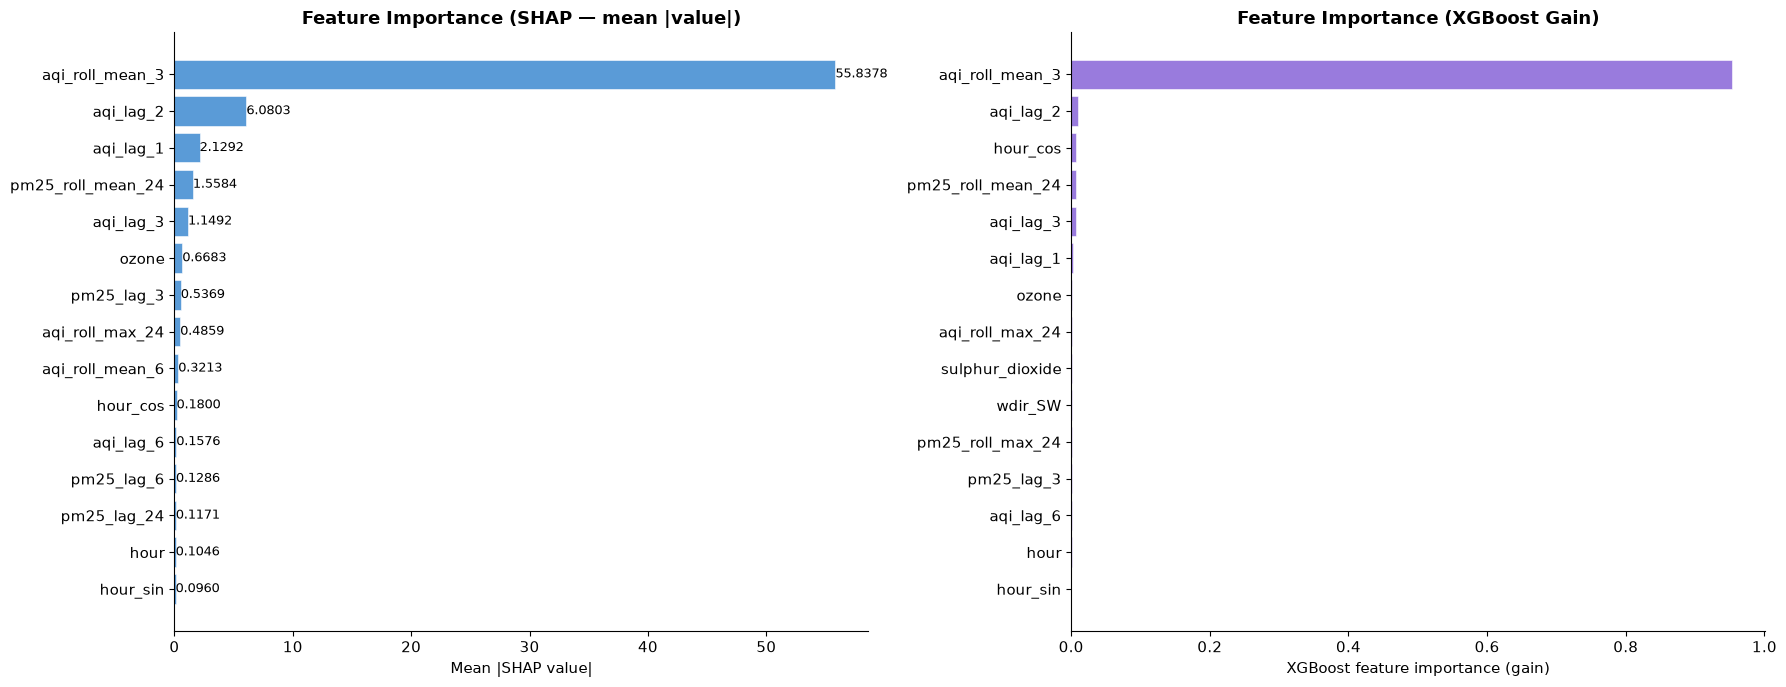

SHAP summary saved to model/shap_summary.csv


In [18]:
# SHAP summary plot (beeswarm)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: bar chart of top features
top_features = mean_abs_shap.head(15)
bars = axes[0].barh(top_features.index[::-1], top_features.values[::-1],
                     color='#3182ce', alpha=0.8, edgecolor='white', lw=0.5)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Feature Importance (SHAP — mean |value|)', fontweight='bold')
for bar, val in zip(bars, top_features.values[::-1]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

# Right: feature importance from XGBoost gain
top_gain = importance_df.head(15)
axes[1].barh(top_gain['Feature'][::-1], top_gain['Importance'][::-1],
             color='#805ad5', alpha=0.8, edgecolor='white', lw=0.5)
axes[1].set_xlabel('XGBoost feature importance (gain)')
axes[1].set_title('Feature Importance (XGBoost Gain)', fontweight='bold')

plt.tight_layout()
plt.savefig('model/feature_importance_plot.png', dpi=150, bbox_inches='tight')
plt.show()


shap_summary = pd.DataFrame({
    'Feature':    mean_abs_shap.index,
    'Mean_SHAP':  mean_abs_shap.values,
})
shap_summary.to_csv('model/shap_summary.csv', index=False)
print('SHAP summary saved to model/shap_summary.csv')

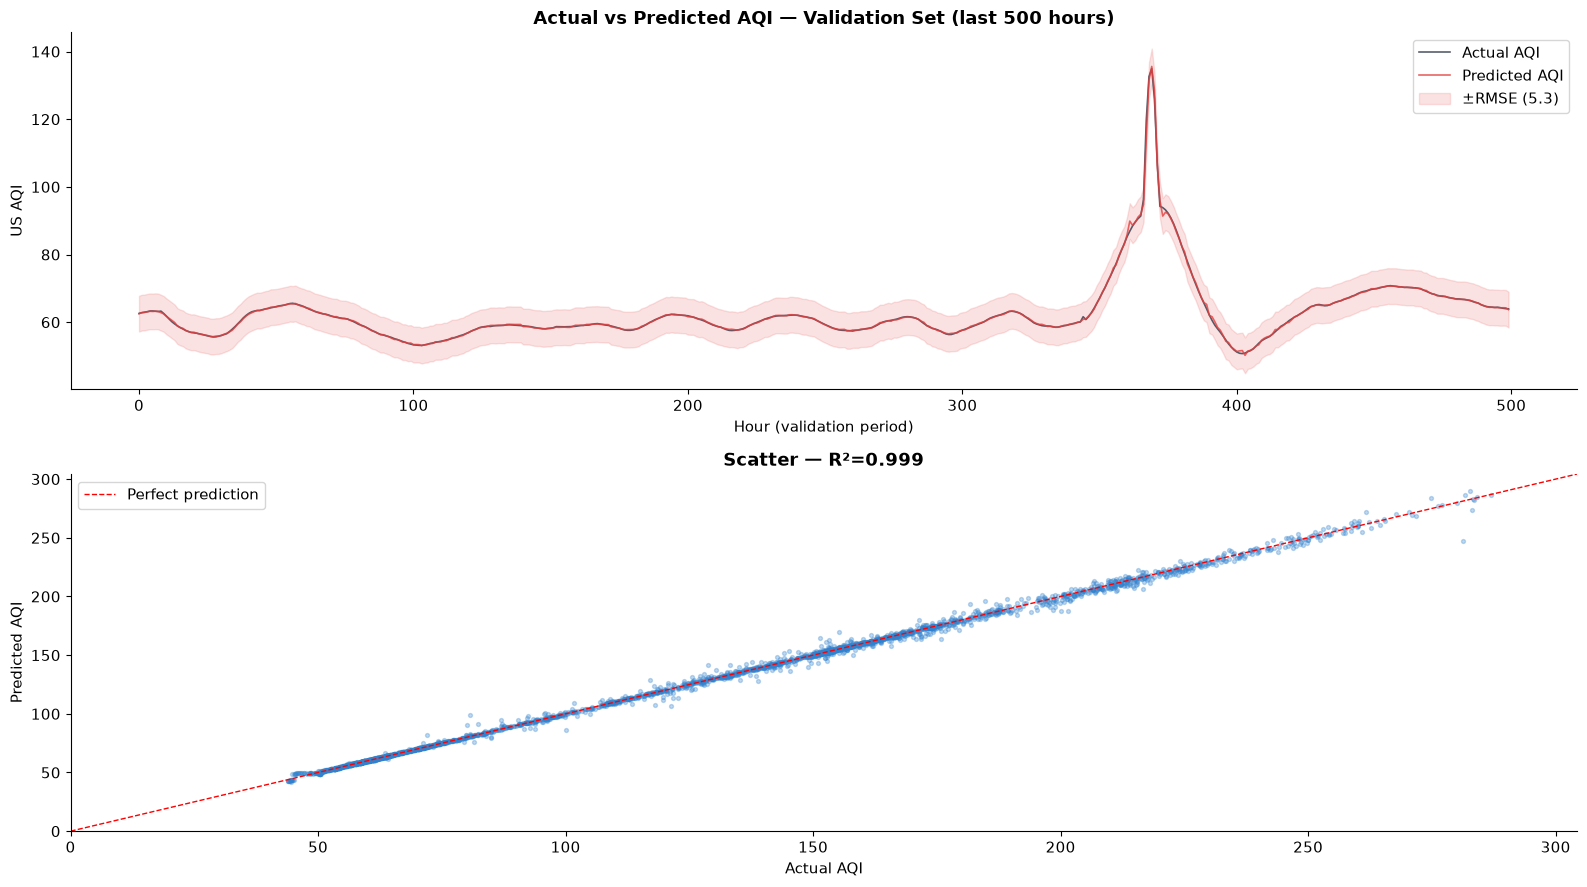

Validation plot saved.


In [21]:
# ── Prediction vs Actual plot ─────────────────────────────────────────────────
for _, (train_idx, val_idx) in enumerate(tscv.split(X)):
    pass  

X_last_val = X[val_idx]
y_last_val = y[val_idx]
dates_val  = df_model.iloc[val_idx]['time'].values if 'time' in df_model.columns else np.arange(len(val_idx))

val_model = xgb.XGBRegressor(**{**best_params, 'random_state': 42, 'n_jobs': -1})
val_model.fit(X[train_idx], y[train_idx], verbose=False)
y_val_pred = val_model.predict(X_last_val)

sample_n = min(500, len(y_last_val))
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Time series
axes[0].plot(range(sample_n), y_last_val[:sample_n], lw=1.2, color='#2d3748', label='Actual AQI', alpha=0.8)
axes[0].plot(range(sample_n), y_val_pred[:sample_n], lw=1.2, color='#e53e3e', label='Predicted AQI', alpha=0.8)
axes[0].fill_between(range(sample_n),
                     y_val_pred[:sample_n] - cv_summary['rmse_mean'],
                     y_val_pred[:sample_n] + cv_summary['rmse_mean'],
                     alpha=0.15, color='#e53e3e', label=f'±RMSE ({cv_summary["rmse_mean"]:.1f})')
axes[0].set_title(f'Actual vs Predicted AQI — Validation Set (last {sample_n} hours)', fontweight='bold')
axes[0].set_ylabel('US AQI')
axes[0].legend()
axes[0].set_xlabel('Hour (validation period)')

# Scatter
axes[1].scatter(y_last_val, y_val_pred, alpha=0.3, s=8, color='#3182ce')
lim = [0, max(y_last_val.max(), y_val_pred.max()) * 1.05]
axes[1].plot(lim, lim, 'r--', lw=1, label='Perfect prediction')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Actual AQI'); axes[1].set_ylabel('Predicted AQI')
axes[1].set_title(f'Scatter — R²={r2_score(y_last_val, y_val_pred):.3f}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model/prediction_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Validation plot saved.')

In [23]:
print('='*50)
print('MODEL v3 TRAINING COMPLETE')
print('='*50)
print(f'Training rows  : {len(df_model):,}')
print(f'Features       : {len(FEATURE_COLS)}')
print(f'Optuna trials  : {N_TRIALS}')
print(f'CV RMSE        : {cv_summary["rmse_mean"]:.2f} ± {cv_summary["rmse_std"]:.2f}')
print(f'CV R²          : {cv_summary["r2_mean"]:.4f} ± {cv_summary["r2_std"]:.4f}')
print(f'Best RMSE (Optuna): {study.best_value:.3f}')
print()
print('Outputs saved to model/')
print('  xgb_model_v2.pkl    — trained model')
print('  feature_cols_v2.pkl — ordered feature list')
print('  feature_importance.csv')
print('  shap_summary.csv')
print('  best_params.json')
print('  cv_summary.json')

MODEL v3 TRAINING COMPLETE
Training rows  : 21,115
Features       : 77
Optuna trials  : 100
CV RMSE        : 5.28 ± 2.32
CV R²          : 0.9787 ± 0.0223
Best RMSE (Optuna): 1.734

Outputs saved to model/
  xgb_model_v2.pkl    — trained model
  feature_cols_v2.pkl — ordered feature list
  feature_importance.csv
  shap_summary.csv
  best_params.json
  cv_summary.json
